In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data
telcom_data = pd.read_csv('/home/chethan/Documents/MONISH/machine_learning/chapter_1/Machine_Learning_Projects/chapter2/datasets/iranian+churn+dataset/Customer Churn.csv')

In [2]:
telcom_data.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


In [3]:
# Initial inspection
telcom_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Call  Failure            3150 non-null   int64  
 1   Complains                3150 non-null   int64  
 2   Subscription  Length     3150 non-null   int64  
 3   Charge  Amount           3150 non-null   int64  
 4   Seconds of Use           3150 non-null   int64  
 5   Frequency of use         3150 non-null   int64  
 6   Frequency of SMS         3150 non-null   int64  
 7   Distinct Called Numbers  3150 non-null   int64  
 8   Age Group                3150 non-null   int64  
 9   Tariff Plan              3150 non-null   int64  
 10  Status                   3150 non-null   int64  
 11  Age                      3150 non-null   int64  
 12  Customer Value           3150 non-null   float64
 13  Churn                    3150 non-null   int64  
dtypes: float64(1), int64(13)

In [4]:
telcom_data.describe()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
count,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000
mean,7.627937,0.076508,32.541905,0.942857,4472.459683,69.460635,73.174921,23.509841,2.826032,1.077778,1.248254,30.998413,470.972916,0.157143
std,7.263886,0.265851,8.573482,1.521072,4197.908687,57.413308,112.237560,17.217337,0.892555,0.267864,0.432069,8.831095,517.015433,0.363993
min,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,15.000000,0.000000,0.000000
25%,1.000000,0.000000,30.000000,0.000000,1391.250000,27.000000,6.000000,10.000000,2.000000,1.000000,1.000000,25.000000,113.801250,0.000000
50%,6.000000,0.000000,35.000000,0.000000,2990.000000,54.000000,21.000000,21.000000,3.000000,1.000000,1.000000,30.000000,228.480000,0.000000
75%,12.000000,0.000000,38.000000,1.000000,6478.250000,95.000000,87.000000,34.000000,3.000000,1.000000,1.000000,30.000000,788.388750,0.000000
max,36.000000,1.000000,47.000000,10.000000,17090.000000,255.000000,522.000000,97.000000,5.000000,2.000000,2.000000,55.000000,2165.280000,1.000000


In [5]:
telcom_data.isnull().sum()

Call  Failure              0
Complains                  0
Subscription  Length       0
Charge  Amount             0
Seconds of Use             0
Frequency of use           0
Frequency of SMS           0
Distinct Called Numbers    0
Age Group                  0
Tariff Plan                0
Status                     0
Age                        0
Customer Value             0
Churn                      0
dtype: int64

In [6]:
# Check for duplicates
print("Number of duplicates:", telcom_data.duplicated().sum())

# Remove duplicates
telcom_data = telcom_data.drop_duplicates()

Number of duplicates: 300


In [7]:
telcom_data.shape

(2850, 14)

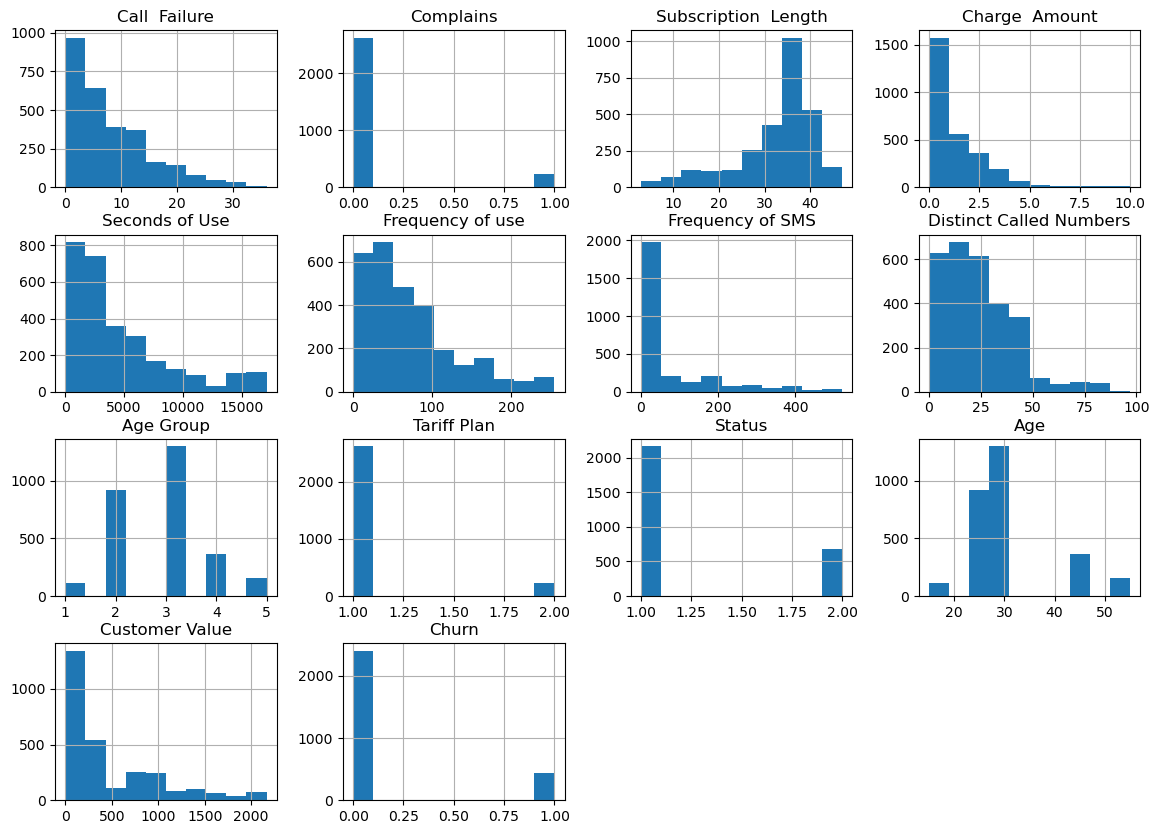

In [8]:
telcom_data.hist(grid=True , figsize=(14,10))
plt.show()

In [9]:
telcom_data.corrwith(telcom_data["Customer Value"]).sort_values(ascending=False)

Customer Value             1.000000
Frequency of SMS           0.922852
Seconds of Use             0.408536
Frequency of use           0.394647
Distinct Called Numbers    0.275447
Tariff Plan                0.249999
Charge  Amount             0.161852
Subscription  Length       0.113184
Call  Failure              0.110228
Complains                 -0.136989
Age Group                 -0.193461
Age                       -0.227174
Churn                     -0.287078
Status                    -0.403568
dtype: float64

#### Never use highly correlated features

In [10]:
telcom_data.drop(columns=["Frequency of SMS"] , inplace=True)

In [11]:
# import seaborn as sns
# plt.figure(figsize=(12, 8))
# sns.heatmap(telcom_data.select_dtypes(include=[np.number]), annot=True, cmap='coolwarm', fmt='.2f')
# plt.title("Heatmap of Numerical Data")
# plt.show()

#### there are features that are highly imbalanced such as 
#### "Complains",'Tariff Plan', 'Status',"Churn"


In [12]:
##ill do later

In [33]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer , StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics.pairwise import rbf_kernel

log_pipeline = make_pipeline(
                        SimpleImputer(strategy="mean"),
                        FunctionTransformer(np.log1p , inverse_func=np.exp , feature_names_out="one-to-one"),
                        StandardScaler()
)

num_pipeline = make_pipeline(
                        SimpleImputer(strategy="mean"),
                        FunctionTransformer(rbf_kernel),
                        StandardScaler()

)
num_cols = telcom_data.columns.drop("Customer Value").tolist()

preprocessing = ColumnTransformer([
                ("log" , log_pipeline , ["Seconds of Use"]),
                ("num" , num_pipeline , num_cols),
] , remainder = num_pipeline)

preprocessing
from sklearn.model_selection import train_test_split

train_set , test_set = train_test_split(telcom_data , test_size=0.3 , random_state=30)
X_train = train_set.drop(columns=["Customer Value"])
y_train = train_set["Customer Value"].copy()
from sklearn.linear_model import LinearRegression

lin_reg = make_pipeline(preprocessing , LinearRegression())

lin_reg.fit(X= X_train, y=y_train)

/home/chethan/Documents/MONISH/machine_learning/chapter_1/.conda/lib/python3.10/site-packages/sklearn/preprocessing/_function_transformer.py:202: UserWarning: The provided functions are not strictly inverse of each other. If you are sure you want to proceed regardless, set 'check_inverse=False'.
  warnings.warn(


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer()),
                                                             ('functiontransformer',
                                                              FunctionTransformer(func=<function rbf_kernel at 0x7f229cd65b40>)),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('log',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('functiontransformer',
                                                                   FunctionTransfor...
                                                                   SimpleImputer()),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(func=<function rbf_kernel at 0x7f229cd65b40>)),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['Call  Failure', 'Complains',
                                                   'Subscription  Length',
                                                   'Charge  Amount',
                                                   'Seconds of Use',
                                                   'Frequency of use',
                                                   'Distinct Called Numbers',
                                                   'Age Group', 'Tariff Plan',
                                                   'Status', 'Age',
                                                   'Churn'])])),
                ('linearregression', LinearRegression())])

In [36]:
# X_test = test_set.drop(columns=["Customer Value"])
# y_test = test_set["Customer Value"].copy()

# X_test = preprocessing.transform(X_test)
# # Predict
# y_pred = lin_reg.predict(X_test)

# # Print results (for example using R^2 score)
# from sklearn.metrics import r2_score
# print(f"R^2 Score: {r2_score(y_test, y_pred)}")